In [3]:
# On ajoute le dossier src/ au chemin de recherche Python
# pour pouvoir importer notre fonction de nettoyage.
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from clean import load_and_clean

# Style visuel agréable et cohérent pour tous les graphiques
sns.set_theme(style="whitegrid")

# Charger les données déjà nettoyées grâce à notre module
# On adapte le chemin car le notebook est dans notebooks/
df = load_and_clean("../data/telco_churn.csv")

print("Données chargées et nettoyées :", df.shape)
df.head()

Données chargées et nettoyées : (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Nombre de clients par catégorie :
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Répartition en pourcentage :
Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64


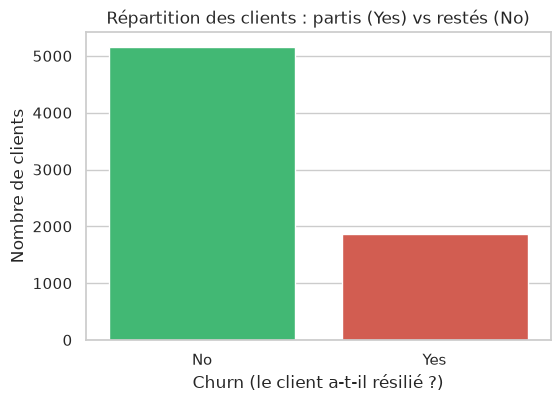

In [4]:
# Compter combien de clients partent (Yes) vs restent (No)
compte_churn = df["Churn"].value_counts()
print("Nombre de clients par catégorie :")
print(compte_churn)

# Calculer les pourcentages (plus parlant que les nombres bruts)
pourcentage_churn = df["Churn"].value_counts(normalize=True) * 100
print("\nRépartition en pourcentage :")
print(pourcentage_churn.round(1))

# Créer le graphique : un diagramme en barres
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", hue="Churn", palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("Répartition des clients : partis (Yes) vs restés (No)")
plt.xlabel("Churn (le client a-t-il résilié ?)")
plt.ylabel("Nombre de clients")
plt.show()

Taux de churn (%) par type de contrat :
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


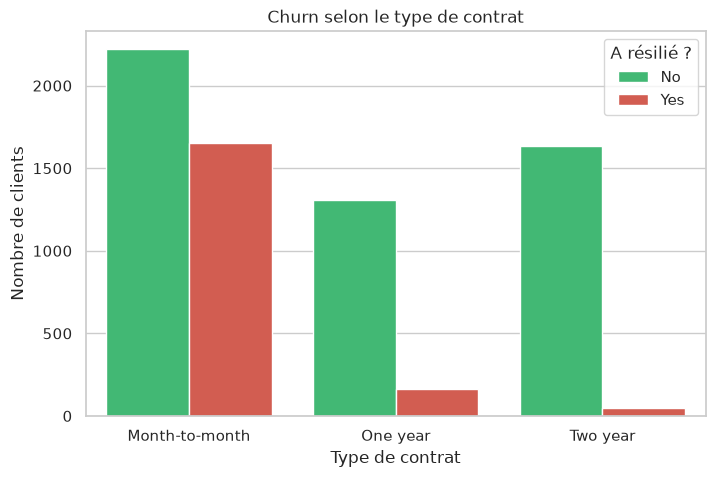

In [5]:
# Croiser le type de contrat avec le churn.
# normalize="index" : pour CHAQUE type de contrat, quelle proportion part vs reste.
churn_par_contrat = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
print("Taux de churn (%) par type de contrat :")
print(churn_par_contrat.round(1))

# Visualiser
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn", palette=["#2ecc71", "#e74c3c"])
plt.title("Churn selon le type de contrat")
plt.xlabel("Type de contrat")
plt.ylabel("Nombre de clients")
plt.legend(title="A résilié ?")
plt.show()

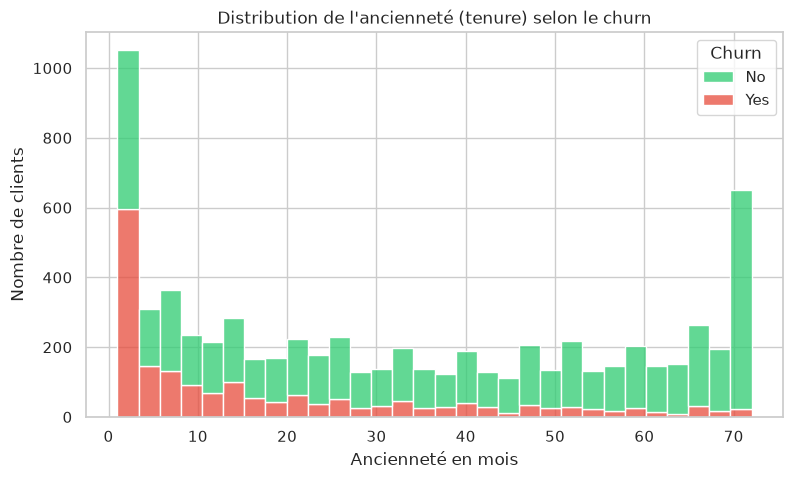

Ancienneté moyenne (en mois) par groupe :
Churn
No     37.7
Yes    18.0
Name: tenure, dtype: float64


In [6]:
# tenure est numérique (mois d'ancienneté) : on compare sa DISTRIBUTION
# entre ceux qui partent et ceux qui restent.
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack",
             palette=["#2ecc71", "#e74c3c"], bins=30)
plt.title("Distribution de l'ancienneté (tenure) selon le churn")
plt.xlabel("Ancienneté en mois")
plt.ylabel("Nombre de clients")
plt.show()

# Comparer l'ancienneté moyenne des deux groupes
anciennete_moyenne = df.groupby("Churn")["tenure"].mean()
print("Ancienneté moyenne (en mois) par groupe :")
print(anciennete_moyenne.round(1))